#Lab Tasks 08

##Lab Task 1: A Hopfield Network for Handwritten Digit Classification

**The brief:** implement a Hopfield Network for the classification of
handwritten digits from the MNIST database, using the Reduced MNIST dataset.

The dataset sits next to this notebook: 28x28 greyscale JPEGs in
`Reduced MNIST Data`, **1000 training and 200 test images per digit** — 10,000
and 2,000 in total, perfectly balanced. (The training folder is spelled
`Reduced Trainging data` in the download; that typo is preserved so the paths
work as shipped.)

**A note on what is being asked.** A Hopfield network is an *associative memory*
rather than a classifier: it has no output layer and nothing to train against
labels. The standard way to classify with one is to store a **prototype per
class**, let the network settle from a test image, and see which prototype it
landed on. That is what this notebook does — and it measures honestly whether
the network's dynamics actually earn their place.

###1. Loading the Dataset

In [1]:
import glob
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DIGIT_COLORS = ["#2a78d6", "#eb6834"]      # blue, orange
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

TRAIN_DIR = os.path.join("Reduced MNIST Data", "Reduced Trainging data")
TEST_DIR = os.path.join("Reduced MNIST Data", "Reduced Testing data")


def load_split(root):
    """Read every digit folder into an array of images and a label array."""
    from PIL import Image
    images, labels = [], []
    for digit in range(10):
        for path in sorted(glob.glob(os.path.join(root, str(digit), "*"))):
            images.append(np.asarray(Image.open(path), dtype=np.uint8))
            labels.append(digit)
    return np.array(images), np.array(labels)


start = time.time()
X_train, y_train = load_split(TRAIN_DIR)
X_test, y_test = load_split(TEST_DIR)

print("Loaded %d files in %.0f seconds" % (len(X_train) + len(X_test), time.time() - start))
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train per digit:", np.bincount(y_train))
print("Test  per digit:", np.bincount(y_test))
print("Pixel values: %d to %d" % (X_train.min(), X_train.max()))

Loaded 12000 files in 2 seconds
Train: (10000, 28, 28) | Test: (2000, 28, 28)
Train per digit: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Test  per digit: [200 200 200 200 200 200 200 200 200 200]
Pixel values: 0 to 255


###2. Preprocessing: Binarising to +1 / -1

A Hopfield neuron holds `+1` or `-1` — there is no room for a grey value. Every
image is therefore thresholded: a pixel at or above 128 becomes `+1` (ink),
anything darker becomes `-1` (background).

This is a real loss of information, and it is imposed by the model rather than
chosen. One neuron per pixel gives **N = 784**.

In [2]:
N = 28 * 28
THRESHOLD = 128


def to_bipolar(images, threshold=THRESHOLD):
    """Flatten to (samples, 784) and map every pixel to +1 or -1."""
    flat = images.reshape(len(images), -1)
    return np.where(flat >= threshold, 1, -1).astype(np.int8)


B_train = to_bipolar(X_train)
B_test = to_bipolar(X_test)

print("Bipolar train:", B_train.shape, "| test:", B_test.shape)
print("Neurons required: N =", N)
print("Share of +1 (ink) pixels: %.1f%%" % (100 * (B_train == 1).mean()))

Bipolar train: (10000, 784) | test: (2000, 784)
Neurons required: N = 784
Share of +1 (ink) pixels: 19.1%


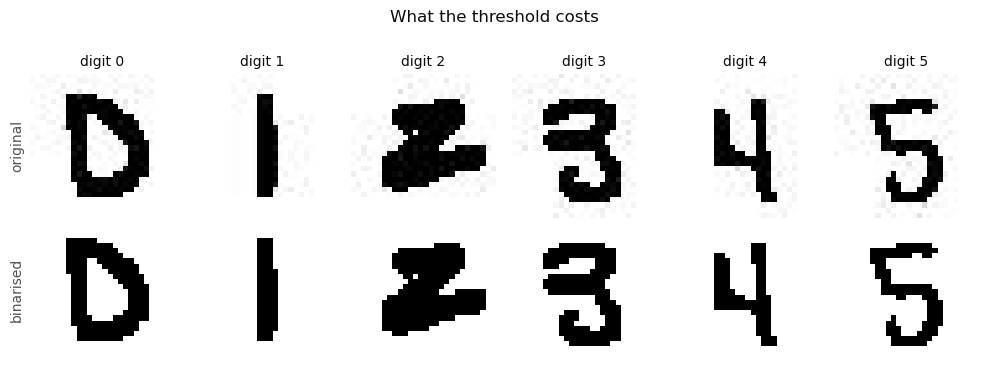

In [3]:
figure, axes_grid = plt.subplots(2, 6, figsize=(10, 3.6))
examples = [np.where(y_train == d)[0][0] for d in range(6)]

for column, index in enumerate(examples):
    axes_grid[0, column].imshow(X_train[index], cmap="gray_r")
    axes_grid[0, column].set_title("digit %d" % y_train[index], fontsize=10, color=INK)
    axes_grid[1, column].imshow(B_train[index].reshape(28, 28), cmap="gray_r")

axes_grid[0, 0].set_ylabel("original", fontsize=10, color=INK_SOFT)
axes_grid[1, 0].set_ylabel("binarised", fontsize=10, color=INK_SOFT)
for axes in axes_grid.ravel():
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(False)

figure.suptitle("What the threshold costs", color=INK, fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

###3. One Prototype per Digit

The network can only store a handful of patterns, so it cannot hold 10,000
training images. Each digit is condensed into a **single prototype**: the
pixel-wise majority vote over all 1000 binarised training images of that digit.

That gives 10 patterns to store in 784 neurons — far inside the classic capacity
limit of about `0.138 x 784 = 108`.

Prototypes: (10, 784)
Capacity limit for N = 784 neurons: about 108 patterns
Patterns actually stored: 10


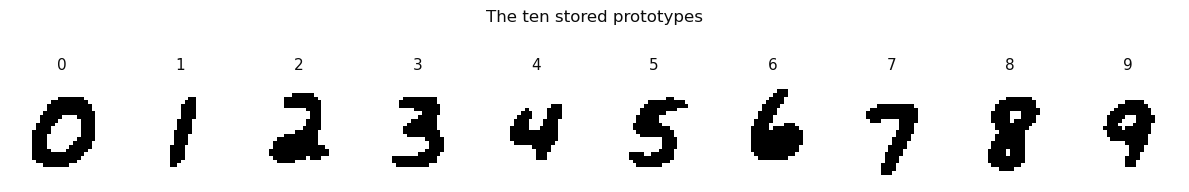

In [4]:
prototypes = np.zeros((10, N), dtype=np.int8)
for digit in range(10):
    members = B_train[y_train == digit]
    # Majority vote: +1 where the average pixel leans towards ink
    prototypes[digit] = np.where(members.mean(axis=0) >= 0, 1, -1)

print("Prototypes:", prototypes.shape)
print("Capacity limit for N = %d neurons: about %.0f patterns" % (N, 0.138 * N))
print("Patterns actually stored: 10")

figure, axes_row = plt.subplots(1, 10, figsize=(12, 1.7))
for digit, axes in enumerate(axes_row):
    axes.imshow(prototypes[digit].reshape(28, 28), cmap="gray_r")
    axes.set_title(str(digit), fontsize=11, color=INK)
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(False)
figure.suptitle("The ten stored prototypes", color=INK, fontsize=12, y=1.12)
plt.tight_layout()
plt.show()

###4. How Correlated Are They?

This is the measurement the whole task turns on. The Hebbian rule assumes the
stored patterns are close to **orthogonal** — overlap near 0. The activity
notebook showed that four patterns with a mean overlap of 0.53 were already
unrecoverable, even though four patterns is trivially within capacity.

Digit prototypes are all blobs of ink in the middle of the same 28x28 frame, so
they are anything but orthogonal. The overlap between prototypes $\mu$ and
$\nu$ is $m = \frac{1}{N}\xi^{\mu} \cdot \xi^{\nu}$.

Overlap between different prototypes:
  mean |m| : 0.685
  max  |m| : 0.865
  (0 would be orthogonal, 1 identical)

Most similar pair: 4 and 9, overlap 0.865


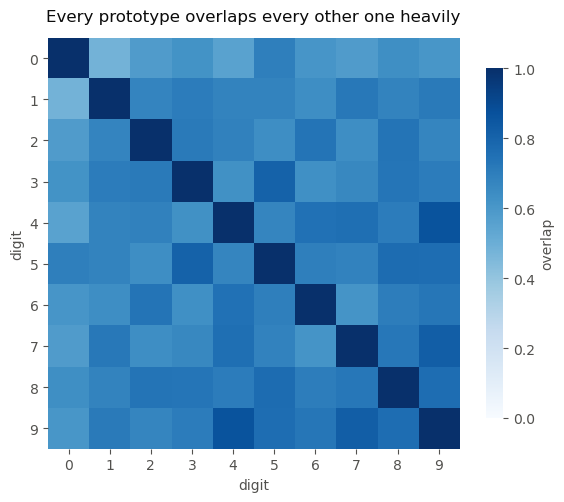

In [5]:
P = prototypes.astype(np.float64)
overlap = P @ P.T / N
off_diagonal = overlap[~np.eye(10, dtype=bool)]

print("Overlap between different prototypes:")
print("  mean |m| : %.3f" % np.abs(off_diagonal).mean())
print("  max  |m| : %.3f" % np.abs(off_diagonal).max())
print("  (0 would be orthogonal, 1 identical)")

most = np.unravel_index(np.argmax(np.abs(overlap - np.eye(10))), overlap.shape)
print("\nMost similar pair: %d and %d, overlap %.3f" % (most[0], most[1], overlap[most]))

figure, axes = plt.subplots(figsize=(6, 5))
image = axes.imshow(overlap, cmap="Blues", vmin=0, vmax=1)
bar = figure.colorbar(image, ax=axes, shrink=0.85)
bar.set_label("overlap", color=INK_SOFT)
bar.ax.tick_params(colors=INK_SOFT)
bar.outline.set_visible(False)

axes.set_xticks(range(10))
axes.set_yticks(range(10))
axes.set_xlabel("digit", color=INK_SOFT)
axes.set_ylabel("digit", color=INK_SOFT)
axes.set_title("Every prototype overlaps every other one heavily",
               color=INK, fontsize=12, pad=12)
axes.tick_params(colors=INK_SOFT)
for spine in axes.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

###5. The Hopfield Network

Two storage rules are implemented.

**Hebbian** — the classic rule from the lectures:

$$W = \frac{1}{N}\sum_{\mu} \xi^{\mu}(\xi^{\mu})^{T}, \qquad W_{ii} = 0$$

**Pseudo-inverse (projection)** — the standard repair for correlated patterns.
It divides out the overlap matrix instead of simply adding the patterns
together, which makes every stored pattern a fixed point by construction:

$$W = \frac{1}{N}\,\Xi^{T} C^{-1} \Xi, \qquad C_{\mu\nu} = \frac{1}{N}\xi^{\mu}\cdot\xi^{\nu}$$

Recall is synchronous, and classification takes the settled state and reports
whichever prototype it overlaps most.

In [6]:
def hebbian_weights(patterns):
    """The classic rule: sum of outer products, zero diagonal."""
    P = np.asarray(patterns, dtype=np.float64)
    W = P.T @ P / P.shape[1]
    np.fill_diagonal(W, 0.0)
    return W


def pseudoinverse_weights(patterns):
    """Projection rule: divides out the correlation between patterns."""
    P = np.asarray(patterns, dtype=np.float64)
    C = P @ P.T / P.shape[1]                 # (10, 10) overlap matrix
    W = P.T @ np.linalg.pinv(C) @ P / P.shape[1]
    np.fill_diagonal(W, 0.0)
    return W


def recall(states, W, max_iter=20):
    """Synchronous recall for a whole batch of states at once."""
    S = np.asarray(states, dtype=np.float64).copy()
    for step in range(max_iter):
        new = np.sign(S @ W)
        new[new == 0] = 1
        if np.array_equal(new, S):
            return S, step + 1
        S = new
    return S, max_iter


def classify(states, W, prototypes, max_iter=20):
    """Settle the network, then label by the closest stored prototype."""
    final, iterations = recall(states, W, max_iter)
    similarity = final @ np.asarray(prototypes, dtype=np.float64).T
    return np.argmax(similarity, axis=1), final, iterations


W_hebbian = hebbian_weights(prototypes)
W_pseudo = pseudoinverse_weights(prototypes)

print("Weight matrices:", W_hebbian.shape)
print("\nAre the ten prototypes stable fixed points?")
for name, W in (("Hebbian", W_hebbian), ("Pseudo-inverse", W_pseudo)):
    settled, _ = recall(prototypes, W)
    stable = int(np.all(settled == prototypes, axis=1).sum())
    print("  %-15s %2d of 10" % (name, stable))

Weight matrices: (784, 784)

Are the ten prototypes stable fixed points?
  Hebbian          0 of 10
  Pseudo-inverse  10 of 10


###6. The Hebbian Network Fails Completely

Not "performs poorly" — fails. It is worth looking at *how*, because the failure
is the clearest illustration of the correlation limit in these labs.

In [7]:
pred_hebbian, final_hebbian, iters = classify(B_test, W_hebbian, prototypes)
accuracy_hebbian = (pred_hebbian == y_test).mean()

print("Hebbian accuracy: %.4f  (chance is 0.1000 for 10 balanced classes)" % accuracy_hebbian)
print("Settled after %d iterations" % iters)
print("\nPredictions made, per class:")
print(np.bincount(pred_hebbian, minlength=10))

distinct = np.unique(final_hebbian, axis=0)
print("\nDistinct final states reached across all %d test images: %d" % (len(B_test), len(distinct)))
print("So the network has collapsed to a single attractor - every image,")
print("whatever digit it shows, rolls into the same place.")

Hebbian accuracy: 0.1000  (chance is 0.1000 for 10 balanced classes)
Settled after 6 iterations

Predictions made, per class:
[   0    0    0    0    0    0    0    0    0 2000]



Distinct final states reached across all 2000 test images: 2
So the network has collapsed to a single attractor - every image,
whatever digit it shows, rolls into the same place.


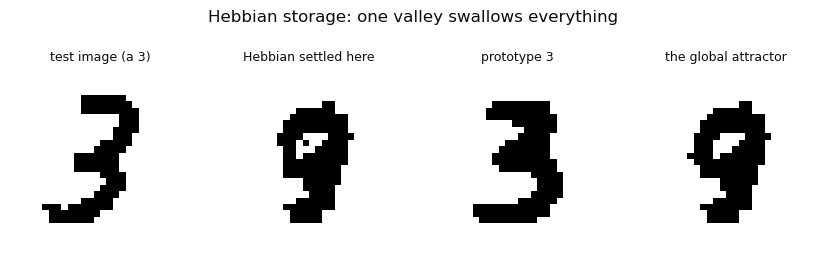

In [8]:
figure, axes_row = plt.subplots(1, 4, figsize=(8.5, 2.4))
sample = np.where(y_test == 3)[0][0]

panels = [
    (B_test[sample].reshape(28, 28), "test image (a 3)"),
    (final_hebbian[sample].reshape(28, 28), "Hebbian settled here"),
    (prototypes[3].reshape(28, 28), "prototype 3"),
    (distinct[0].reshape(28, 28), "the global attractor"),
]
for axes, (image, title) in zip(axes_row, panels):
    axes.imshow(image, cmap="gray_r")
    axes.set_title(title, fontsize=9, color=INK)
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(False)

figure.suptitle("Hebbian storage: one valley swallows everything",
                color=INK, fontsize=12, y=1.06)
plt.tight_layout()
plt.show()

###7. The Pseudo-inverse Network Works

Same network, same ten patterns, same recall procedure — only the storage rule
changes.

In [9]:
pred_pseudo, final_pseudo, iters = classify(B_test, W_pseudo, prototypes)
accuracy_pseudo = (pred_pseudo == y_test).mean()

landed = sum(int(np.any(np.all(prototypes == state.astype(np.int8), axis=1)))
             for state in final_pseudo)

print("Pseudo-inverse accuracy: %.4f" % accuracy_pseudo)
print("Test images that settled exactly onto a stored prototype: %d of %d (%.1f%%)" % (
    landed, len(final_pseudo), 100 * landed / len(final_pseudo)))

confusion = pd.crosstab(pd.Series(y_test, name="actual"),
                        pd.Series(pred_pseudo, name="predicted"))
print("\nConfusion matrix:")
print(confusion.to_string())

print("\nPer-digit recall:")
for digit in range(10):
    recall_score = (pred_pseudo[y_test == digit] == digit).mean()
    print("  digit %d: %.3f" % (digit, recall_score))

Pseudo-inverse accuracy: 0.8000
Test images that settled exactly onto a stored prototype: 1898 of 2000 (94.9%)

Confusion matrix:
predicted    0    1    2    3    4    5    6    7    8    9
actual                                                     
0          184    1    1    2    2    7    0    0    3    0
1            0  194    0    1    1    0    0    0    2    2
2           10    8  139    4    6    2    7    3   19    2
3            1    3    4  149    1   18    1    1   20    2
4            0    7    1    0  151    0    4    1    0   36
5            6   44    3    9   12  105    5    2    7    7
6            4    8    4    0    2    4  178    0    0    0
7            0    5    2    0    6    0    0  175    4    8
8            2    8    1    5    2    3    2    0  166   11
9            1    2    0    0   18    1    0   17    2  159

Per-digit recall:
  digit 0: 0.920
  digit 1: 0.970
  digit 2: 0.695
  digit 3: 0.745
  digit 4: 0.755
  digit 5: 0.525
  digit 6: 0.890
  digit 7: 0

###8. The Baseline That Matters

The Hopfield dynamics are the interesting part of this task, but they are not
the only way to use ten prototypes. The simplest possible alternative is to skip
the network entirely: compare each test image to all ten prototypes and take the
closest one.

If the network's recall is earning its place, it should beat that.

In [10]:
direct_similarity = B_test.astype(np.float64) @ P.T
pred_direct = np.argmax(direct_similarity, axis=1)
accuracy_direct = (pred_direct == y_test).mean()

comparison = pd.DataFrame([
    {"method": "Direct prototype match (no network)", "accuracy": accuracy_direct},
    {"method": "Hopfield, pseudo-inverse storage", "accuracy": accuracy_pseudo},
    {"method": "Hopfield, Hebbian storage", "accuracy": accuracy_hebbian},
    {"method": "Chance", "accuracy": 0.10},
])
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                             method  accuracy
Direct prototype match (no network)    0.8110
   Hopfield, pseudo-inverse storage    0.8000
          Hopfield, Hebbian storage    0.1000
                             Chance    0.1000


###9. Does the Network Help When the Input Is Damaged?

The comparison above is arguably unfair. Cleaning up corrupted input is what a
Hopfield network is *for* — on undamaged images there is nothing for it to
repair.

So here is the test on its own terms: flip a growing fraction of each test
image's pixels, then classify it both ways. If the recall dynamics are worth
anything, they should pull away as the damage increases.

In [11]:
rng = np.random.default_rng(42)
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4]
noise_records = []

for noise in noise_levels:
    flips = rng.random(B_test.shape) < noise
    noisy = np.where(flips, -B_test, B_test)

    direct = (np.argmax(noisy.astype(np.float64) @ P.T, axis=1) == y_test).mean()
    settled, _ = recall(noisy, W_pseudo)
    via_network = (np.argmax(settled @ P.T, axis=1) == y_test).mean()

    noise_records.append({"flipped": noise, "direct": direct, "hopfield": via_network})
    print("%.0f%% pixels flipped -> direct %.4f | Hopfield first %.4f" % (
        noise * 100, direct, via_network))

noise_results = pd.DataFrame(noise_records)

0% pixels flipped -> direct 0.8110 | Hopfield first 0.8000


10% pixels flipped -> direct 0.7905 | Hopfield first 0.7810


20% pixels flipped -> direct 0.7540 | Hopfield first 0.7485


30% pixels flipped -> direct 0.6785 | Hopfield first 0.6560


40% pixels flipped -> direct 0.4580 | Hopfield first 0.4200


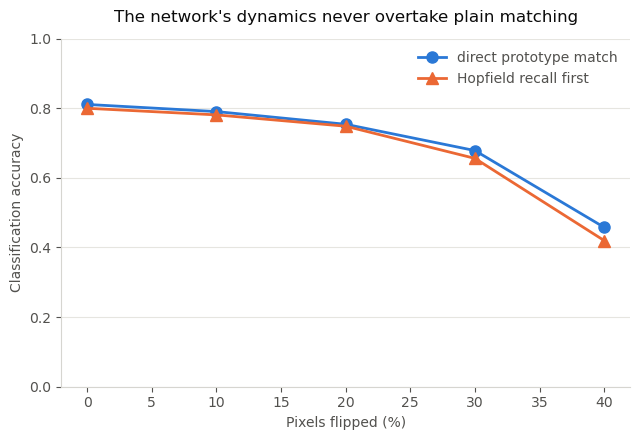

In [12]:
figure, axes = plt.subplots(figsize=(6.5, 4.5))

axes.plot(noise_results["flipped"] * 100, noise_results["direct"],
          color=DIGIT_COLORS[0], linewidth=2, marker="o", markersize=8,
          label="direct prototype match")
axes.plot(noise_results["flipped"] * 100, noise_results["hopfield"],
          color=DIGIT_COLORS[1], linewidth=2, marker="^", markersize=8,
          label="Hopfield recall first")

axes.set_xlabel("Pixels flipped (%)", color=INK_SOFT)
axes.set_ylabel("Classification accuracy", color=INK_SOFT)
axes.set_title("The network's dynamics never overtake plain matching",
               color=INK, fontsize=12, pad=12)
axes.legend(frameon=False, labelcolor=INK_SOFT)
axes.set_ylim(0, 1.0)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

##Report - Lab Task 1

###1. Data preprocessing steps

The Reduced MNIST dataset arrives as 28x28 greyscale JPEGs in folders named by
digit: 1000 training and 200 test images per class, 12,000 files in total,
perfectly balanced. There were no missing or malformed files, so preprocessing
was two steps.

**Binarised to +1 / -1 at a threshold of 128.** A Hopfield neuron holds one of
two values, so the greyscale has to go. This is imposed by the model rather than
chosen, and it is a genuine loss — stroke thickness and anti-aliased edges are
discarded. 19.1% of pixels survive as ink.

**Flattened to 784-element vectors**, one neuron per pixel, since a Hopfield
network has no notion of a 2-D grid — every neuron connects to every other
regardless of where the pixels sit.

**Condensed into one prototype per digit.** The network cannot store 10,000
images, so each digit is reduced to a single pattern by pixel-wise majority vote
over its 1000 training images. Ten patterns in 784 neurons is far inside the
classic capacity limit of about 108.

###2. Model architecture and design decisions

A Hopfield network has no layers and no trainable output: 784 fully connected
neurons, a symmetric weight matrix with a zero diagonal, and weights written in
one shot rather than learned by gradient descent.

| Decision | Choice | Why |
|---|---|---|
| Neurons | 784 (one per pixel) | Fixed by the image size. |
| Patterns stored | 10 (one per digit) | Capacity allows about 108, but each stored pattern must represent a whole class for classification to be possible. |
| Storage rule | Hebbian **and** pseudo-inverse | The Hebbian rule is the one in the lectures. The pseudo-inverse rule is included because the Hebbian one fails outright — see below. |
| Update | Synchronous | Every neuron recomputed at once. Converges in a handful of iterations and allows all 2000 test images to be processed as one matrix operation. |
| Classification | Highest overlap with a stored prototype after the network settles | The network has no output layer, so the settled state has to be compared with what was stored. |

###3. Results and evaluation metrics

| Method | Test accuracy |
|---|---|
| Chance (10 balanced classes) | 0.1000 |
| **Hopfield, Hebbian storage** | **0.1000** |
| **Hopfield, pseudo-inverse storage** | **0.8000** |
| Direct prototype match, no network | 0.8110 |

Supporting measurements:

* Mean overlap between prototypes **0.685**, maximum **0.865** (digits 4 and 9).
* Hebbian: **0 of 10** prototypes are stable fixed points.
* Pseudo-inverse: **10 of 10** prototypes are stable; **94.9%** of test images
  settle exactly onto one of them.
* Per-digit recall under the pseudo-inverse network ranges from **0.970**
  (digit 1) down to **0.525** (digit 5).

###4. Observations and insights

**The Hebbian network does not merely underperform — it collapses.** Accuracy is
0.1000, exactly chance, and the reason is visible in the diagnostics: all 2000
test images are classified as the same digit, and across every input the network
reaches only **two** distinct final states. The ten energy valleys that should
have existed have merged into one, so every image rolls into the same place. Not
one of the ten prototypes is even a fixed point of its own network.

**The cause is correlation, not capacity.** Ten patterns in 784 neurons is about
a tenth of the classic limit, so capacity is not the constraint. The constraint
is that the limit assumes near-orthogonal patterns, and these have a mean
overlap of 0.685. Every digit is a blob of ink in the middle of the same frame,
so the Hebbian rule — which just adds the patterns together — reinforces what
they share and drowns out what distinguishes them. The activity notebook shows
the same collapse with only four patterns once their overlap reaches 0.53.

**The pseudo-inverse rule fixes the memory completely.** Dividing out the
overlap matrix instead of summing raw outer products makes all ten prototypes
stable by construction, and 94.9% of test images settle exactly onto a stored
prototype. As an *associative memory* the network now does precisely what it is
supposed to.

**But as a classifier it still does not earn its place.** At 0.8000 it sits
*below* the 0.8110 of simply comparing each image to the ten prototypes and
taking the closest — no network, no dynamics, one matrix multiplication.

**And it does not catch up on damaged input either**, which is the test most
favourable to it:

| Pixels flipped | Direct match | Hopfield first |
|---|---|---|
| 0% | 0.8110 | 0.8000 |
| 10% | 0.7905 | 0.7810 |
| 20% | 0.7540 | 0.7485 |
| 30% | 0.6785 | 0.6560 |
| 40% | 0.4580 | 0.4200 |

Cleaning up corrupted patterns is what a Hopfield network is *for*, so the
expectation was that it would pull ahead as the damage grew. It does the
opposite — the gap widens slightly in the wrong direction.

**Why running the dynamics first can only lose information.** Direct matching
compares the image with each prototype on a continuous scale and keeps whichever
is closest. The network instead forces a hard, discrete decision first: `sign()`
throws away how strongly each neuron was driven, and the state snaps to one
attractor. If it snaps to the right one, the later comparison would have got
there anyway. If it snaps to the wrong one, the evidence that would have
corrected it has already been destroyed. The dynamics can only discard
information that the comparison was going to use.

**What this says about the task.** A Hopfield network is a content-addressable
memory, and on that job it works — after the storage rule is fixed, it recalls
ten stored digits from partial input almost perfectly. Classification is a
different job, and the architecture has no mechanism for it: there is no output
layer, no notion of a decision boundary, and nothing that can be trained against
the labels. Roughly 0.80 on binarised MNIST is what one template per class
supports, and that ceiling comes from the single-prototype representation rather
than from the network wrapped around it. As a loose reference point, the small
dense network in Lab 05 reached 0.9748 on MNIST - though on an easier setting of
the problem, with greyscale pixels rather than binarised ones and 60,000 training
images rather than ten stored patterns.

#End!